# MDS-UPDRS  

Clinical measurements using the MDS-UPDRS questionnaire have been recorded at regular intervals for most of the PPMI participants and are stored in the following tables that mirror the different sections of the form, some of which are completed by a medical professional and some of which are completed by the participant.  
- MDS-UPDRS_Part_I 
- MDS-UPDRS_Part_I_Patient_Questionnaire 
- MDS_UPDRS_Part_II__Patient_Questionnaire 
- MDS-UPDRS_Part_III 
- MDS-UPDRS_Part_III_ON_OFF_Determination___
- MDS-UPDRS_Part_IV__Motor_Complications

Note the following:  
1. Occasionally there can be missing MDS-UPDRS measurements. These will normally appear as NULL values but in part 3 of MDS-UPDRS can also appear with a value of “101” which means “unable to rate”. In the above example visits with missing values were excluded by adding checks for nulls in the join statements. Alternative approaches are to set NULLs to a default value like zero (not recommended) or to impute a value such as a mean. Users should consider what missing value treatment is most appropriate based on their specific research question(s).  
   
2. Sometimes there are multiple MDS-UPDRS measurements on the same date. These are because measurements may be taken when the participant is experiencing a medication “on” period and when the participant is experiencing an “off” period. In the above example we used the MAX function to take the maximum score on a given day, thereby ensuring just one value (the “worst case”) per date. Alternatives are either to take all values or filter on either “on” or “off” values. To filter on “on”/”off”, use column PDSTATE on MDS_UPDRS_Part_III though note that in a small number of cases this field is missing data (NULL value), in which case you need instead query the PAG_NAME field which will have a value of NUPDR3OF or NUPDR3ON20. See also the document “Methods for Defining PD Med Use” available from the download page under the folder Study Docs/Study Methods.  
   
3. The MDS-UPDRS scores can fluctuate over time, i.e., they can go down as well as  up. This can be caused by a number of factors including changes to levodopa and other medication, subjectivity of measurements and normal fluctuation of MDS-UPDRS scores, for example resulting from “on” and “off” periods. Typically, the score taken during an “off” period will be higher (i.e. worse) than the score taken during an “on” period, but this may not always be the case for the reasons just outlined. The long-term trend is for MDS-UPDRS scores to increase; for example, over a large population of people with PD, on average we see a 2.5 to 3 point annual increase in MDS-UPDRS part III scores measured in the off state.

In [55]:
import pandas as pd
import numpy as np


# ==========================================
# Load data
# ==========================================
mds_part_1 = pd.read_csv(
    "/home/falconnier/Documents/PPMI_study_data_starting_point/MDS-UPDRS_Part_I_12Feb2026.csv"
)
mds_part_1p = pd.read_csv(
    "/home/falconnier/Documents/PPMI_study_data_starting_point/MDS-UPDRS_Part_I_Patient_Questionnaire_12Feb2026.csv"
)
mds_part_2p = pd.read_csv(
    "/home/falconnier/Documents/PPMI_study_data_starting_point/MDS_UPDRS_Part_II__Patient_Questionnaire_12Feb2026.csv"
)
mds_part_3 = pd.read_csv(
    "/home/falconnier/Documents/PPMI_study_data_starting_point/MDS-UPDRS_Part_III_12Feb2026.csv"
)
mds_part_4 = pd.read_csv(
    "/home/falconnier/Documents/PPMI_study_data_starting_point/MDS-UPDRS_Part_IV__Motor_Complications_12Feb2026.csv"
)
# ==========================================
# date format
# ==========================================

# Pick dataset that contains all participants
all_patients = mds_part_1["PATNO"].dropna().unique()
np.random.seed(42)
PATIENT_ID = np.random.choice(all_patients)
print("Randomly selected patient:", PATIENT_ID)

Randomly selected patient: 40520


/tmp/ipykernel_201198/1698608000.py:17: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  mds_part_3 = pd.read_csv(


In [56]:
print(mds_part_2p.columns)

Index(['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'NUPSOURC',
       'NP2SPCH', 'NP2SALV', 'NP2SWAL', 'NP2EAT', 'NP2DRES', 'NP2HYGN',
       'NP2HWRT', 'NP2HOBB', 'NP2TURN', 'NP2TRMR', 'NP2RISE', 'NP2WALK',
       'NP2FREZ', 'NP2PTOT', 'ORIG_ENTRY', 'LAST_UPDATE'],
      dtype='object')


In [57]:
# ==========================================
# Filter to selected participant
# ==========================================
mds_part_1 = mds_part_1[mds_part_1["PATNO"] == PATIENT_ID]

print(mds_part_1.head(1))

# ==========================================
# Keep only the required columns BEFORE merging
# ==========================================

mds_part_1 = mds_part_1[["PATNO", "INFODT", "EVENT_ID", "NP1RTOT"]]
mds_part_1p = mds_part_1p[["PATNO", "INFODT", "EVENT_ID", "NP1PTOT"]]
mds_part_2p = mds_part_2p[["PATNO", "INFODT", "EVENT_ID", "NP2PTOT"]]
mds_part_3 = mds_part_3[
    ["PATNO", "INFODT", "EVENT_ID", "NP3TOT", "NHY", "PDSTATE", "PAG_NAME"]
]
mds_part_3 = mds_part_3[
    ["PATNO", "INFODT", "EVENT_ID", "NP3TOT", "NHY", "PDSTATE", "PAG_NAME"]
]
mds_part_4 = mds_part_4[["PATNO", "INFODT", "EVENT_ID", "NP4TOT"]]
# ==========================================
# Merge dataframes on PATNO, INFODT, and EVENT_ID
# ==========================================


merged = (
    mds_part_1.merge(mds_part_1p, on=["PATNO", "INFODT", "EVENT_ID"], how="inner")
    .merge(mds_part_2p, on=["PATNO", "INFODT", "EVENT_ID"], how="inner")
    .merge(mds_part_3, on=["PATNO", "INFODT", "EVENT_ID"], how="inner")
    .merge(mds_part_4, on=["PATNO", "INFODT", "EVENT_ID"], how="inner")
)


# ==========================================
# Remove missing values
# ==========================================

# Remove NaNs
merged = merged.dropna(
    subset=["NP1RTOT", "NP1PTOT", "NP2PTOT", "NP3TOT", "NP4TOT", "NHY"]
)

# Remove Part III "unable to rate" (101)
merged = merged[merged["NP3TOT"] != 101]

# TODO handle the case with on off

# ==========================================
# Select relevant columns
# ==========================================
merged = merged[
    ["INFODT", "EVENT_ID", "NP1RTOT", "NP1PTOT", "NP2PTOT", "NP3TOT", "NP4TOT", "NHY"]
]

# ==========================================
# Aggregate per visit (if required)
# ==========================================

progression = (
    merged.groupby(["INFODT", "EVENT_ID"], as_index=False)
    .agg(
        {
            "NP1RTOT": "max",
            "NP1PTOT": "max",
            "NP2PTOT": "max",
            "NP3TOT": "max",
            "NHY": "max",
        }
    )
    .rename(
        columns={
            "NP1RTOT": "Part1",
            "NP1PTOT": "Part1P",
            "NP2PTOT": "Part2",
            "NP3TOT": "Part3",
            "NHY": "HY_Stage",
        }
    )
    .sort_values(["INFODT", "EVENT_ID"])
)


print(progression.head(10))


          REC_ID  PATNO EVENT_ID PAG_NAME   INFODT  NUPSOURC  NP1COG  NP1HALL  \
10539  525227201  40520       BL  NUPDRS1  06/2015       1.0       0        0   

       NP1DPRS  NP1ANXS  NP1APAT  NP1DDS  NP1RTOT ORIG_ENTRY  \
10539      1.0      1.0      0.0     0.0      2.0    06/2015   

               LAST_UPDATE  
10539  2020-06-26 17:59:32  
Empty DataFrame
Columns: [INFODT, EVENT_ID, Part1, Part1P, Part2, Part3, HY_Stage]
Index: []


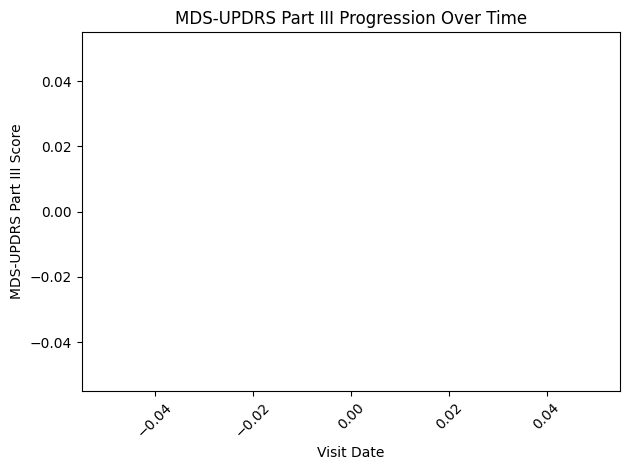

In [58]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(progression["INFODT"], progression["HY_Stage"])
plt.xlabel("Visit Date")
plt.ylabel("MDS-UPDRS Part III Score")
plt.title("MDS-UPDRS Part III Progression Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()